# Assignment 3 — Predicting Car Price III
**Student ID:** st127132  
**Task:** Predict price class 0, 1, 2 or 3 using multinomial logistic regression.

This notebook explains the implementation, reproduces the evaluation, checks the custom metrics against scikit-learn, and documents MLflow and deployment. The reusable code lives in `a3/`; the application is in `app/`.

The starting point is the course [Multinomial Logistic Regression notebook](https://github.com/chaklam-silpasuwanchai/Python-for-Machine-Learning/blob/main/01%20-%20Supervised/02%20-%20Classification/01%20-%20Logistic%20Regression/02%20-%20Multinomial%20Logistic%20Regression.ipynb). I retain its softmax hypothesis, cross-entropy objective, batch gradient update and argmax prediction. Changes include stable log-softmax, a gradient consistent with **mean** loss, a separate bias, optional L2 penalty and classification metrics. The code is adapted rather than API-identical: feature count is inferred, the class count is four, and `lr`/`num_epochs` replace `alpha`/`max_iter`.

**Execution:** Run all cells to inspect the committed experiment outputs and reproduce the held-out evaluation. Set `RUN_EXPERIMENTS = True` below to retrain the 12 configurations. Remote publishing is explicitly disabled by default because it requires network access and credentials.

In [1]:
from pathlib import Path
import sys, os, json, inspect
ROOT = Path.cwd()
if not (ROOT / "a3").is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report as sklearn_report
from a3.data import FEATURES, PRICE_LABELS, clean_data, price_classes
from a3.metrics import classification_report, confusion_matrix
from a3.model import LogisticRegression
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False})

## Task 1 — Preprocessing and four price classes
Reuse the A1/A2 cleaning order: remove CNG/LPG and test-drive cars, map ownership to numbers, parse numeric units, extract brand, drop torque, remove rows missing the four required specifications, and deduplicate after cleaning. Imputation, scaling and one-hot encoding are fitted separately inside each training fold. A3 does not use A2 polynomial features.

The target is the **original selling price in rupees**, not the log price used for regression. Fixed boundaries are chosen before model selection; no full-dataset quantiles or held-out labels are used to derive cutoffs.

| Class | Selling price (INR) |
|---|---|
| 0 | 0 < price ≤ 300,000 |
| 1 | 300,000 < price ≤ 600,000 |
| 2 | 600,000 < price ≤ 1,000,000 |
| 3 | price > 1,000,000 |

These bands are intentionally interpretable rather than equal-frequency. Macro F1 makes each class equally important during model selection, which helps reveal poor performance on less frequent classes. Changing the bands would change the task and its measured accuracy.

Raw rows: 8,128; cleaned rows: 6,607
Training: 5,285; held-out test: 1,322


,train,test
Class,,
0,1787,447
1,2011,503
2,1112,278
3,375,94


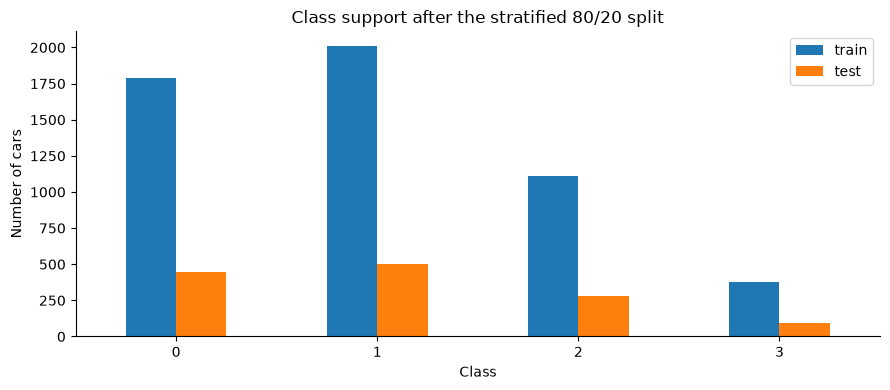

In [2]:
raw = pd.read_csv(ROOT / "data/Cars.csv")
data = clean_data(raw)
X = data[FEATURES]
y = price_classes(data.selling_price)
train_idx, test_idx = train_test_split(np.arange(len(y)), test_size=.2, stratify=y, random_state=42)
print(f"Raw rows: {len(raw):,}; cleaned rows: {len(data):,}")
print(f"Training: {len(train_idx):,}; held-out test: {len(test_idx):,}")
counts = pd.DataFrame({"train": np.bincount(y[train_idx], minlength=4),
                       "test": np.bincount(y[test_idx], minlength=4)}, index=pd.Index(range(4), name="Class"))
display(counts)
counts.plot.bar(rot=0, title="Class support after the stratified 80/20 split", ylabel="Number of cars")
plt.tight_layout()
plt.show()

### Multinomial logistic regression
For a transformed row $x_i$, class probabilities are
$$p_{ic}=\frac{\exp(x_i^T w_c+b_c)}{\sum_{k=0}^{3}\exp(x_i^T w_k+b_k)}.$$
The class with the largest probability is the prediction. Subtracting each row's maximum logit before exponentiation preserves probabilities and avoids numerical overflow. Initialization is zero; unlike a neural network with interchangeable hidden units, this convex softmax classifier does not require random initialization to break hidden-unit symmetry.

The full class is printed below so the notebook contains the actual implementation rather than a separate, potentially inconsistent copy.

In [3]:
print(inspect.getsource(LogisticRegression))

class LogisticRegression(ClassifierMixin, ClassificationMetrics, BaseEstimator):
    """Minimize mean cross entropy + l2 * sum(W**2); do not penalize bias.

    Softmax generalizes the binary sigmoid to four mutually exclusive classes.
    l2=0 disables ridge. The brief uses summed cross entropy; dividing its entire
    objective by m gives our convention with l2 = lambda_in_brief / m.
    """
    def __init__(self, lr=0.1, num_epochs=600, l2=0.0, tol=1e-8):
        self.lr = lr
        self.num_epochs = num_epochs
        self.l2 = l2
        self.tol = tol

    @staticmethod
    def _validate_X(X):
        X = np.asarray(X, dtype=float)
        if X.ndim != 2 or not len(X) or not X.shape[1] or not np.isfinite(X).all():
            raise ValueError("X must be a non-empty finite two-dimensional numeric array")
        return X

    @staticmethod
    def _log_softmax(logits):
        # Subtract the largest logit before exponentiating to prevent overflow.
        shifted = logits - logit

### Metrics from scratch
For class $c$, $TP_c$ counts correct predictions of $c$, $FP_c$ counts other classes predicted as $c$, and $FN_c$ counts actual $c$ predicted as something else.

- Accuracy: all correct predictions divided by all observations.
- Precision: $TP_c/(TP_c+FP_c)$.
- Recall: $TP_c/(TP_c+FN_c)$.
- F1: $2P_cR_c/(P_c+R_c)$.
- Macro average: arithmetic mean of the four class scores.
- Weighted average: $\sum_c (s_c/N)\,\mathrm{score}_c$, where $s_c$ is support.

**What does support mean?** It is the number of actual observations belonging to that class in the evaluated data, not the number predicted as that class.

**Correction to the brief:** the weighted-average example includes an extra division by four. Since the weights already sum to one, that division is omitted to agree with scikit-learn. Macro F1 averages the individual F1 values; it is not the harmonic mean of macro precision and macro recall. Undefined divisions return zero, matching `zero_division=0`.

In [4]:
import a3.metrics as custom_metrics
print(inspect.getsource(custom_metrics))

"""Classification metrics from counts, with sklearn's zero_division=0 convention."""
import numpy as np

LABELS = np.arange(4)


def confusion_matrix(y_true, y_pred, labels=LABELS):
    """Rows are actual classes; columns are predicted classes."""
    y_true, y_pred, labels = map(np.asarray, (y_true, y_pred, labels))
    if y_true.ndim != 1 or y_true.shape != y_pred.shape or not y_true.size:
        raise ValueError("Labels must be non-empty, matching one-dimensional arrays")
    if labels.ndim != 1 or len(np.unique(labels)) != len(labels):
        raise ValueError("labels must be unique and one-dimensional")
    if not np.isin(y_true, labels).all() or not np.isin(y_pred, labels).all():
        raise ValueError("An observation has a label outside the supplied classes")
    return np.array([[np.sum((y_true == a) & (y_pred == b)) for b in labels]
                     for a in labels], dtype=int)


def _divide(numerator, denominator):
    # Undefined precision/recall is zero, even if a cl

In [5]:
mock_true = np.array([0,0,0,1,1,2,3,3])
mock_pred = np.array([0,1,0,1,2,2,0,3])
ours = classification_report(mock_true, mock_pred)
reference = sklearn_report(mock_true, mock_pred, labels=[0,1,2,3], output_dict=True, zero_division=0)
for label in ["0", "1", "2", "3", "macro avg", "weighted avg"]:
    for metric in ["precision", "recall", "f1-score", "support"]:
        np.testing.assert_allclose(ours[label][metric], reference[label][metric], atol=1e-12)
np.testing.assert_allclose(ours["accuracy"], reference["accuracy"], atol=1e-12)
display(pd.DataFrame({k:v for k,v in ours.items() if isinstance(v,dict)}).T)
print("All custom report values match scikit-learn to numerical precision.")
print(sklearn_report(mock_true, mock_pred, labels=[0,1,2,3], zero_division=0))

,precision,recall,f1-score,support
0,0.666667,0.666667,0.666667,3.0
1,0.500000,0.500000,0.500000,2.0
2,0.500000,1.000000,0.666667,1.0
3,1.000000,0.500000,0.666667,2.0
macro avg,0.666667,0.666667,0.625000,8.0
weighted avg,0.687500,0.625000,0.625000,8.0


All custom report values match scikit-learn to numerical precision.
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.50      0.50      0.50         2
           2       0.50      1.00      0.67         1
           3       1.00      0.50      0.67         2

    accuracy                           0.62         8
   macro avg       0.67      0.67      0.62         8
weighted avg       0.69      0.62      0.62         8



## Task 2 — Optional ridge (L2) penalty
The implementation minimizes
$$J(W,b)=-\frac1m\sum_i\log p_{i,y_i}+\lambda\sum_{j,c} W_{jc}^2.$$
Its gradients are
$$\nabla_WJ=X^T(P-Y)/m+2\lambda W,\qquad \nabla_bJ=\operatorname{mean}(P-Y).$$
The intercept is **not penalized**. `l2=0` disables ridge; positive values shrink the weights. The brief writes summed cross entropy, while this implementation uses mean cross entropy. Dividing the brief's entire loss by $m$ gives our convention with `l2 = lambda_in_brief / m`; the numerical strengths are therefore not directly interchangeable.

Unit tests compare every weight and bias gradient against central finite differences, with and without ridge. This independently checks both the loss and its derivative.

In [6]:
RUN_EXPERIMENTS = False
if RUN_EXPERIMENTS:
    from a3.train import run_experiments
    run_experiments()
summary = json.loads((ROOT / "data/a3_best_model_summary.json").read_text())
results = pd.read_csv(ROOT / "data/a3_experiment_results.csv")
display(results[["lr", "l2", "num_epochs", "cv_accuracy", "cv_macro_f1_score", "cv_macro_f1_std"]])

,lr,l2,num_epochs,cv_accuracy,cv_macro_f1_score,cv_macro_f1_std
0,0.30,0.0001,600,0.780322,0.769586,0.013917
1,0.30,0.0000,600,0.780132,0.769546,0.013918
2,0.30,0.0010,600,0.778430,0.765527,0.015066
3,0.10,0.0001,600,0.762535,0.738215,0.015024
4,0.10,0.0000,600,0.762346,0.738067,0.015045
5,0.10,0.0010,600,0.761779,0.737389,0.012334
6,0.30,0.0100,600,0.752696,0.723716,0.014013
7,0.10,0.0100,600,0.744371,0.710436,0.013902
8,0.03,0.0010,600,0.724693,0.680586,0.010800
9,0.03,0.0001,600,0.723179,0.679070,0.011030


### Experiment design and model selection
The grid is 3 learning rates (`0.03`, `0.1`, `0.3`) × 4 L2 strengths (`0`, `0.0001`, `0.001`, `0.01`) = **12 configurations**, each evaluated with the same five stratified folds, 600 epochs and a deterministic split (seed 42). The optimizer is full-batch gradient descent.

Select the highest mean cross-validation macro F1, breaking ties by accuracy and then smaller L2. The selected configuration is fitted on all training rows and evaluated once on the held-out test set. Each candidate's full-training model, parameters and CV metrics are saved in MLflow. Test metrics are attached only to the selected run. No dataset or raw example rows are logged.

**Interpretation of regularization:** the best unregularized CV macro F1 is 0.76955 versus 0.76959 for the selected ridge model. This difference (about 0.00004) is much smaller than the fold variation (~0.014), so it does not establish a meaningful ridge advantage. Stronger L2=0.01 underfits this grid. The learning-rate effect also reflects the fixed 600-epoch budget; the experiment does not prove that all settings reached their optimum.

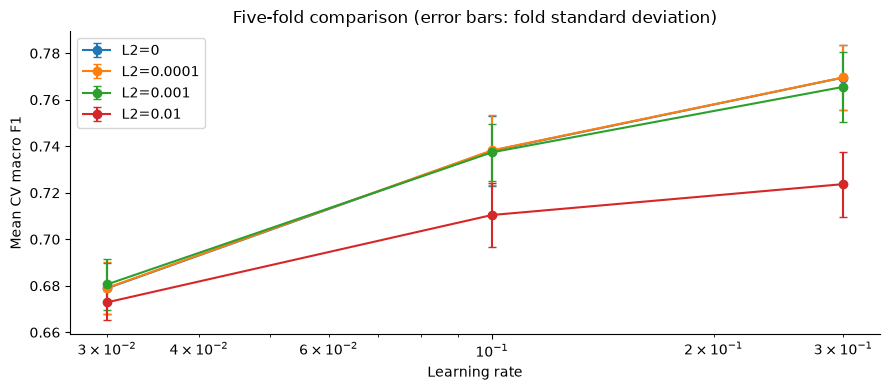

Selected learning rate=0.3, L2=0.0001, CV macro F1=0.7696


In [7]:
fig, ax = plt.subplots()
for l2, group in results.groupby("l2"):
    group = group.sort_values("lr")
    ax.errorbar(group.lr, group.cv_macro_f1_score, yerr=group.cv_macro_f1_std,
                marker="o", capsize=3, label=f"L2={l2:g}")
ax.set(xscale="log", xlabel="Learning rate", ylabel="Mean CV macro F1",
       title="Five-fold comparison (error bars: fold standard deviation)")
ax.legend()
plt.tight_layout()
plt.show()
best = summary["best_config"]
print(f"Selected learning rate={best['lr']}, L2={best['l2']}, CV macro F1={best['cv_macro_f1_score']:.4f}")

In [8]:
pipeline = joblib.load(ROOT / "models/best_a3_model.joblib")
predicted = pipeline.predict(X.iloc[test_idx])
report = classification_report(y[test_idx], predicted)
np.testing.assert_allclose(report["accuracy"], summary["test_metrics"]["test_accuracy"])
ref = sklearn_report(y[test_idx], predicted, labels=[0,1,2,3], output_dict=True, zero_division=0)
for label in ["0", "1", "2", "3", "macro avg", "weighted avg"]:
    for metric in ["precision", "recall", "f1-score", "support"]:
        np.testing.assert_allclose(report[label][metric], ref[label][metric], atol=1e-12)
display(pd.DataFrame({k:v for k,v in report.items() if isinstance(v,dict)}).T)
print(f"Test accuracy: {report['accuracy']:.4f}")
print(f"Majority-class baseline: {summary['majority_baseline_accuracy']:.4f}")

,precision,recall,f1-score,support
0,0.880000,0.836689,0.857798,447.0
1,0.711230,0.793241,0.750000,503.0
2,0.666667,0.633094,0.649446,278.0
3,0.791667,0.606383,0.686747,94.0
macro avg,0.762391,0.717352,0.735998,1322.0
weighted avg,0.764643,0.760968,0.760806,1322.0


Test accuracy: 0.7610
Majority-class baseline: 0.3805


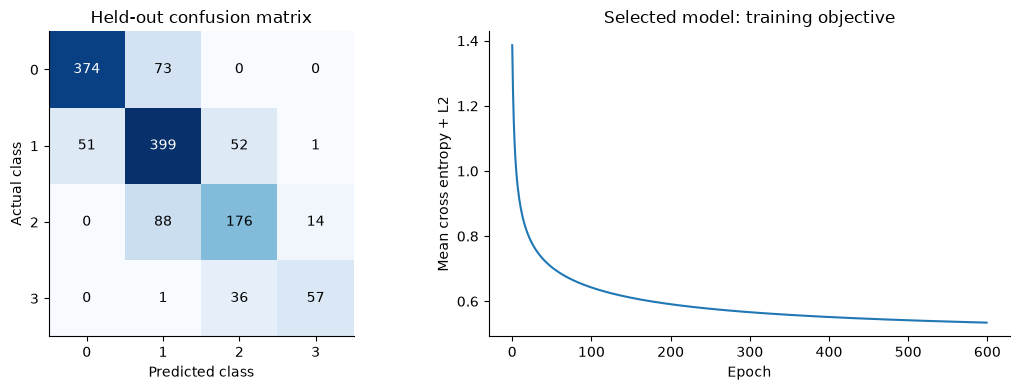

**Interpretation.** The weakest class by F1 is class 2 (Upper mid-range: ₹600,000–1,000,000), with F1 0.649. The classifier uses linear decision boundaries in the encoded feature space; nonlinear interactions and cars close to the price boundaries can still be misclassified. The ordinary multinomial loss treats every wrong class equally and does not explicitly use the ordering of the price bands. Probabilities have not been calibrated.

In [9]:
cm = confusion_matrix(y[test_idx], predicted)
fig, axes = plt.subplots(1,2,figsize=(11,4))
axes[0].imshow(cm, cmap="Blues")
for (r,c), value in np.ndenumerate(cm):
    axes[0].text(c,r,str(value),ha="center",va="center",color="white" if value > cm.max()/2 else "black")
axes[0].set(xticks=range(4), yticks=range(4), xlabel="Predicted class", ylabel="Actual class", title="Held-out confusion matrix")
axes[1].plot(pipeline.named_steps["classifier"].loss_history_)
axes[1].set(xlabel="Epoch", ylabel="Mean cross entropy + L2", title="Selected model: training objective")
plt.tight_layout()
plt.show()
per_class_f1 = np.array([report[str(c)]["f1-score"] for c in range(4)])
weakest = int(per_class_f1.argmin())
display(Markdown(f"**Interpretation.** The weakest class by F1 is class {weakest} ({PRICE_LABELS[weakest]}), "
                 f"with F1 {per_class_f1[weakest]:.3f}. The classifier uses linear decision boundaries in "
                 "the encoded feature space; nonlinear interactions and cars close to the price boundaries "
                 "can still be misclassified. The ordinary multinomial loss treats every wrong class equally "
                 "and does not explicitly use the ordering of the price bands. Probabilities have not been calibrated."))

## Task 3 — MLflow, registry and CI/CD
**Updated endpoint from the course announcement:** `https://mlflow.ml.brain.cs.ait.ac.th`  
**Experiment:** `st127132-a3`  
**Registered model:** `st127132-a3-model`  
**Required stage:** `Staging`

The local experiments are complete. Remote upload, registration and live deployment are separate operations and are not claimed complete until verified. The notebook below sets the required credential environment variables interactively; the password is never placed in notebook source or printed in output. To publish, connect to the course network if needed, set `PUBLISH_REMOTE = True`, and execute the cell. Only this student's experiment and model are touched.

The uploader preserves all 12 candidates' parameters, fold histories and fitted models. It records the local source run IDs, resumes partial uploads, registers the selected candidate and verifies both its Staging state and remote loading. MLflow model stages are deprecated in newer releases, but the explicit Staging requirement is retained rather than silently replaced with an alias.

In [10]:
PUBLISH_REMOTE = False
if PUBLISH_REMOTE:
    from getpass import getpass
    os.environ["MLFLOW_TRACKING_USERNAME"] = "student"
    if not os.environ.get("MLFLOW_TRACKING_PASSWORD"):
        os.environ["MLFLOW_TRACKING_PASSWORD"] = getpass("Course MLflow password: ")
    from a3.publish import publish
    publish()
else:
    receipt = ROOT / "data/a3_remote_receipt.json"
    print(receipt.read_text() if receipt.exists() else "Remote upload/registry: pending; no verified receipt.")

Remote upload/registry: pending; no verified receipt.


### Model unit tests and automated deployment
`tests/test_a3.py` includes the two required tests: expected model inputs and expected output shapes. It also tests custom metrics, finite-difference gradients, numerical stability, learning on separable data, and price-boundary behavior.

The GitHub Actions workflow runs tests on every push and pull request. After successful tests on the repository's default branch, it builds an image tagged with the commit SHA, pushes it to Docker Hub and deploys it by SSH. Docker health checks and an HTTPS health check must pass. Configure the `course-vm` environment with `DOCKERHUB_USERNAME`, `DOCKERHUB_TOKEN`, `A3_SSH_PRIVATE_KEY`, and `A3_SSH_KNOWN_HOSTS` first. Verify SSH host keys using a trusted course source.

A3 runs at the planned path `https://st127132.ml.brain.cs.ait.ac.th/a3/`. This is a configured destination, **not a claim that this version is already live**. The existing root A1/A2 application is retained. See `app/README.md` for local and Docker commands.

In [11]:
import subprocess
completed = subprocess.run([sys.executable, "-m", "unittest", "discover", "-s", "tests", "-v"],
                           cwd=ROOT, capture_output=True, text=True)
print(completed.stdout + completed.stderr)
assert completed.returncode == 0, "Model tests failed"

test_l2_gradient_matches_finite_differences (test_a3.MathematicalTests.test_l2_gradient_matches_finite_differences) ... ok
test_metrics_match_sklearn_including_absent_classes (test_a3.MathematicalTests.test_metrics_match_sklearn_including_absent_classes) ... ok
test_price_boundary_rules (test_a3.MathematicalTests.test_price_boundary_rules) ... ok
test_softmax_is_stable_and_model_learns (test_a3.MathematicalTests.test_softmax_is_stable_and_model_learns) ... ok
/Users/krown/AIT/ML/Assignments/Car_Price_Prediction/venv/lib/python3.14/site-packages/joblib/numpy_pickle.py:207: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  array.shape = self.shape
test_model_output_has_expected_shape (test_a3.ModelContractTests.test_model_output_has_expected_shape)
Task 3 test (2): one class per row, four probabilities per row. ... ok
test_model_takes_expected_input (test_a3

## Submission checklist
- [x] Four-class labels using A1/A2 preprocessing.
- [x] Logistic regression and classification metrics implemented from scratch.
- [x] Custom reports checked against scikit-learn; support explained.
- [x] Optional L2 penalty, documented loss convention and verified gradients.
- [x] Executed experiments, saved model, notebook and README.
- [x] Web application under `app/` and model unit tests.
- [x] GitHub Actions workflow prepared with tests before deployment.
- [ ] Upload runs to the course MLflow server and verify the model in Staging.
- [ ] Configure GitHub secrets, push the changes and verify a successful workflow/deployment.

Local verification does not replace the final two remote requirements.

### References
- Course multinomial logistic regression notebook linked above.
- [scikit-learn classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html).
- [MLflow model registry workflows](https://mlflow.org/docs/latest/ml/model-registry/workflow/).
- [GitHub Actions workflow syntax](https://docs.github.com/en/actions/writing-workflows/workflow-syntax-for-github-actions).
